<a href="https://colab.research.google.com/github/JuarezSSJ/machine_learning/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn import tree

In [3]:
df = pd.read_excel("/content/drive/MyDrive/Machine Learning/data/dados_frutas.xlsx")

In [4]:
df

,Arredondada,Suculenta,Vermelha,Doce,Fruta
0,0,1,1,1,Morango
1,1,0,0,0,Limão
2,1,1,0,1,Pera
3,0,0,0,1,Banana
4,1,1,1,1,Cereja
5,1,1,1,0,Tomate
6,1,1,1,1,Maçã


In [5]:
arvore = tree.DecisionTreeClassifier(random_state=42)

In [6]:
df.head(0)

,Arredondada,Suculenta,Vermelha,Doce,Fruta


In [7]:
#resposta
y = df['Fruta']

caracteristicas = ['Arredondada', 'Suculenta', 'Vermelha', 'Doce']
x = df[caracteristicas]

In [8]:
y

,Fruta
0,Morango
1,Limão
2,Pera
3,Banana
4,Cereja
5,Tomate
6,Maçã


In [9]:
x

,Arredondada,Suculenta,Vermelha,Doce
0,0,1,1,1
1,1,0,0,0
2,1,1,0,1
3,0,0,0,1
4,1,1,1,1
5,1,1,1,0
6,1,1,1,1


In [10]:
arvore.fit(x, y)

DecisionTreeClassifier(random_state=42)

In [11]:
arvore.predict([[0,1,0,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['Morango'], dtype=object)

In [12]:
import matplotlib.pyplot as plt

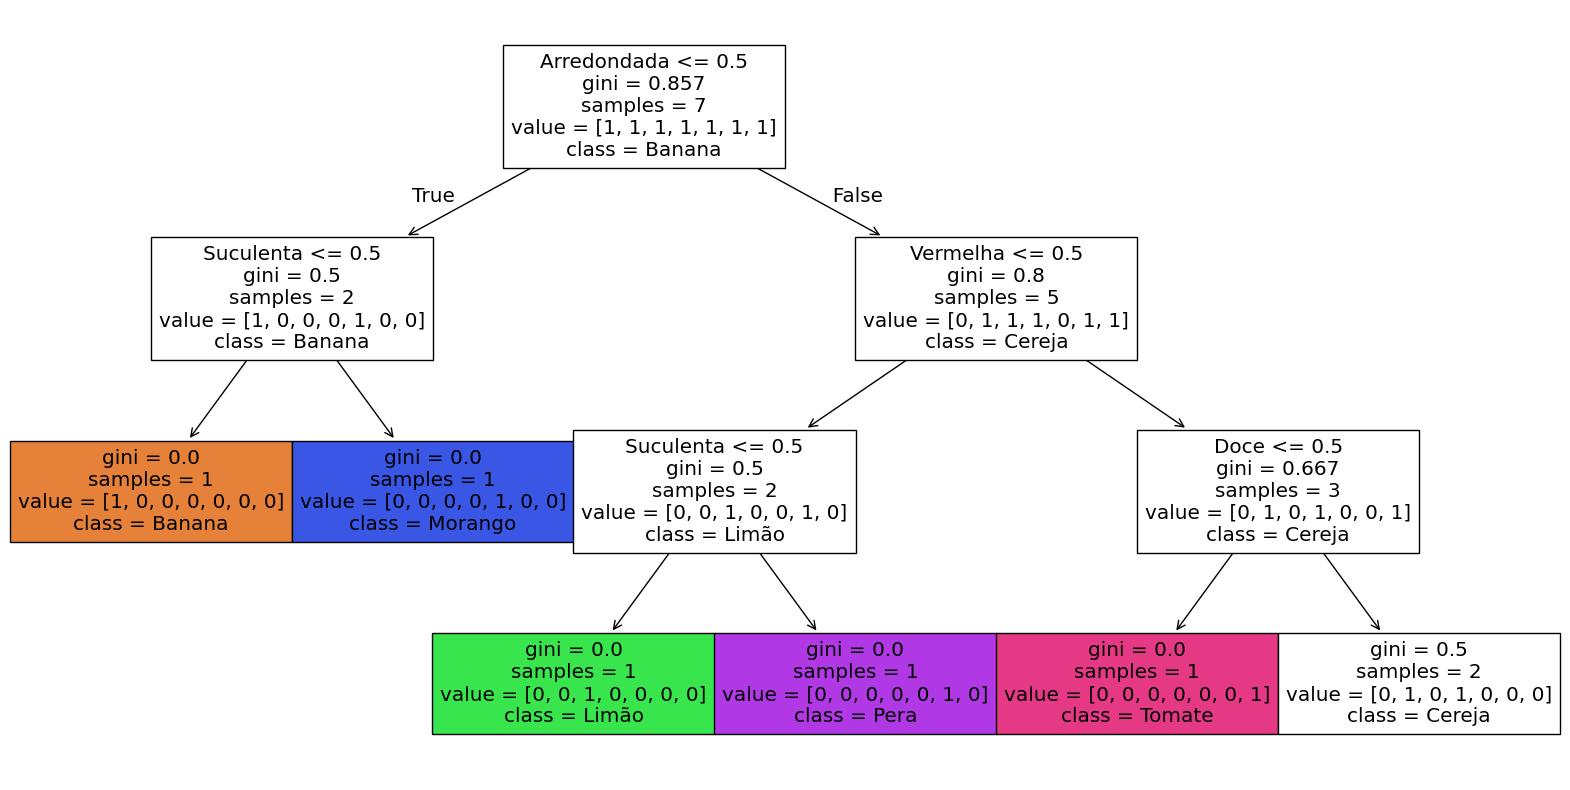

In [13]:
plt.figure(figsize=(20, 10))  # <-- Use isso em vez de plt.fig

tree.plot_tree(arvore, feature_names=caracteristicas, class_names=arvore.classes_ , filled=True)
plt.show()


In [14]:
df.head(0)

,Arredondada,Suculenta,Vermelha,Doce,Fruta


In [15]:
proba = arvore.predict_proba([[1,1,1,1]])[0]
pd.Series(proba, index=arvore.classes_)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


,0
Banana,0.0
Cereja,0.5
Limão,0.0
Maçã,0.5
Morango,0.0
Pera,0.0
Tomate,0.0


In [16]:
df_cerveja = pd.read_excel("/content/drive/MyDrive/Machine Learning/data/dados_cerveja.xlsx")

In [17]:
df_cerveja

,id,temperatura,copo,espuma,cor,classe
0,1,-5,mud,não,escura,weissbier
1,2,-5,mud,sim,escura,weissbier
2,3,-1,pint,não,clara,weissbier
3,4,-1,pint,sim,clara,weissbier
4,5,-5,pint,não,escura,pale-ale
5,6,-5,pint,não,clara,pale-ale
6,7,-5,pint,sim,escura,pale-ale
7,8,-1,mud,não,clara,pilsen
8,9,-5,mud,não,clara,pilsen
9,10,-1,mud,sim,clara,pilsen


In [18]:
y_cerveja = df_cerveja["classe"]

cerveja_caract = ["temperatura", "copo", "espuma", "cor"]
x_cerveja = df_cerveja[cerveja_caract]

In [19]:
x_cerveja = x_cerveja.replace ({
    "mud": 1, "pint":2,
    "sim":1, "não":0,
    "clara":0, "escura":1
})

/tmp/ipykernel_10292/4110143968.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_cerveja = x_cerveja.replace ({


In [20]:
model = tree.DecisionTreeClassifier()

model.fit(x_cerveja, y_cerveja)

DecisionTreeClassifier()

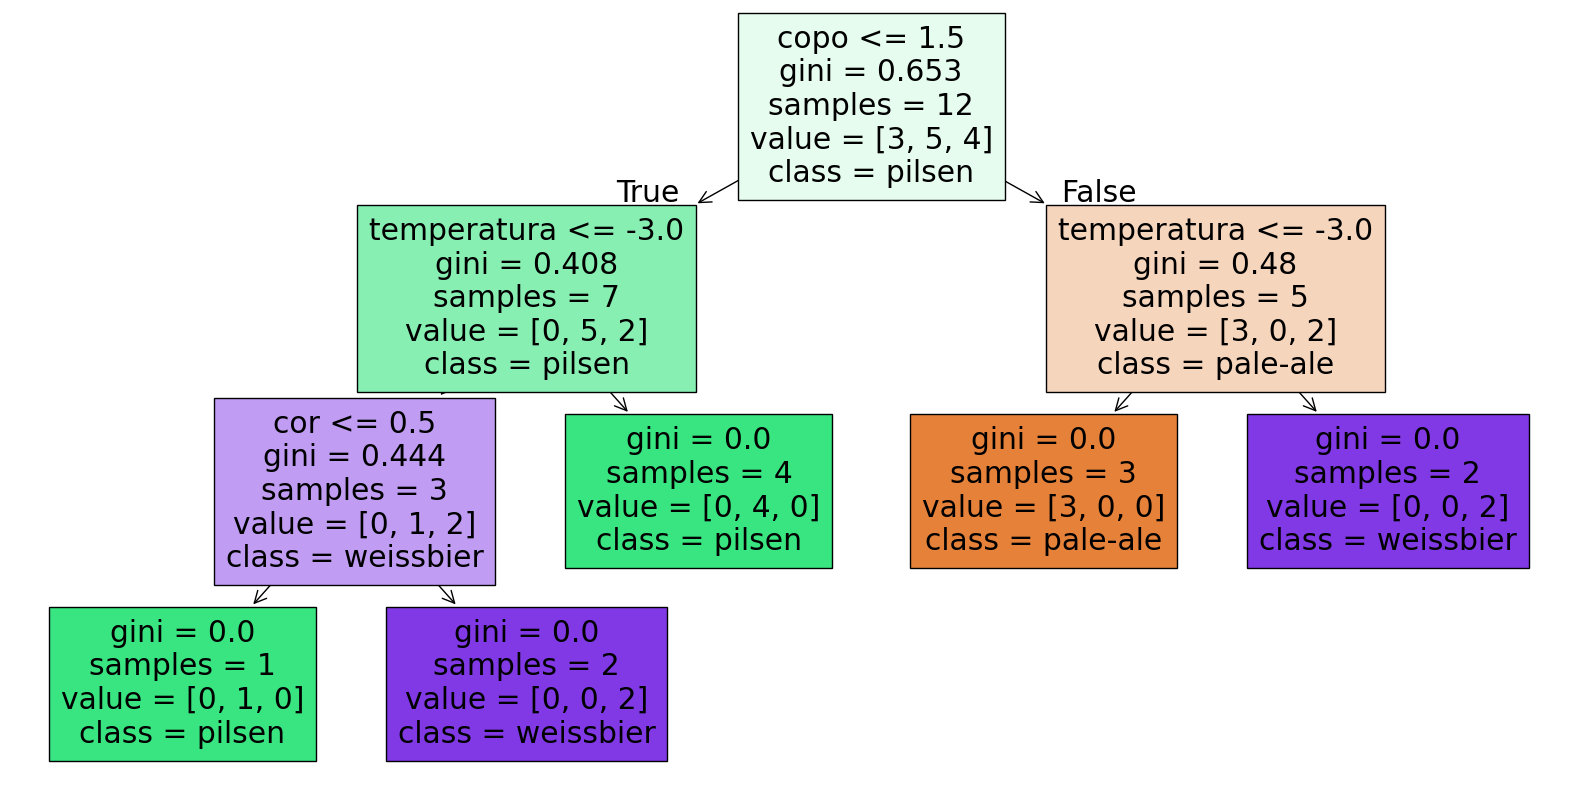

In [21]:
plt.figure(figsize=(20, 10))  # <-- Use isso em vez de plt.fig

tree.plot_tree(model, feature_names=cerveja_caract, class_names=model.classes_ , filled=True)
plt.show()


In [22]:
df_star_wars = pd.read_parquet("/content/drive/MyDrive/Machine Learning/data/dados_clones.parquet")
df_star_wars = df_star_wars.rename(columns={"Status ": "Status"})
df_star_wars.head()

,p2o_master_id,Massa(em kilos),General Jedi encarregado,Estatura(cm),Distância Ombro a ombro,Tamanho do crânio,Tamanho dos pés,Tempo de existência(em meses),Status
0,10578986,83.13,Yoda,180.25,Tipo 4,Tipo 1,Tipo 5,0.0,Defeituoso
1,10976676,83.08,Yoda,180.39,Tipo 3,Tipo 2,Tipo 5,0.0,Defeituoso
2,10588329,83.12,Shaak Ti,180.26,Tipo 4,Tipo 5,Tipo 5,0.0,Defeituoso
3,10254411,83.38,Shaak Ti,180.35,Tipo 2,Tipo 2,Tipo 5,0.0,Defeituoso
4,10634458,83.15,Shaak Ti,180.31,Tipo 3,Tipo 2,Tipo 2,0.0,Defeituoso


In [23]:
dados_Dist_Ombro = df_star_wars["Distância Ombro a ombro"].unique()
dados_Dist_Ombro.sort()
dados_Dist_Ombro

array(['Tipo 1', 'Tipo 2', 'Tipo 3', 'Tipo 4', 'Tipo 5'], dtype=object)

In [24]:
dados_status = df_star_wars["Status"].unique()
dados_status

array(['Defeituoso', 'Apto'], dtype=object)

In [25]:
dados_tempo = df_star_wars["Tempo de existência(em meses)"].unique()
dados_tempo.sort()
dados_tempo

array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9,
       11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. ,
       12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. , 13.1,
       13.2, 13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14. , 14.1, 14.2,
       14.3, 14.4, 14.5, 14.6, 14.7, 14.8, 14.9, 15

In [26]:
df_star_wars = df_star_wars.replace({
    'Tipo 1': 1, 'Tipo 2': 2, 'Tipo 3': 3, 'Tipo 4': 4, 'Tipo 5':5,
    'Defeituoso': 0, 'Apto': 1
})

/tmp/ipykernel_10292/243738458.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_star_wars = df_star_wars.replace({


In [27]:
print(df_star_wars.head(0))

Empty DataFrame
Columns: [p2o_master_id, Massa(em kilos), General Jedi encarregado, Estatura(cm), Distância Ombro a ombro, Tamanho do crânio, Tamanho dos pés, Tempo de existência(em meses), Status]
Index: []


In [28]:
y_star = df_star_wars["General Jedi encarregado"]

star_caract = ["Massa(em kilos)", "Estatura(cm)", "Distância Ombro a ombro", "Tamanho do crânio", "Tamanho dos pés", "Tempo de existência(em meses)", "Status"]
x_star = df_star_wars[star_caract]

In [29]:
model_star = tree.DecisionTreeClassifier()

model_star.fit(x_star, y_star)

DecisionTreeClassifier()

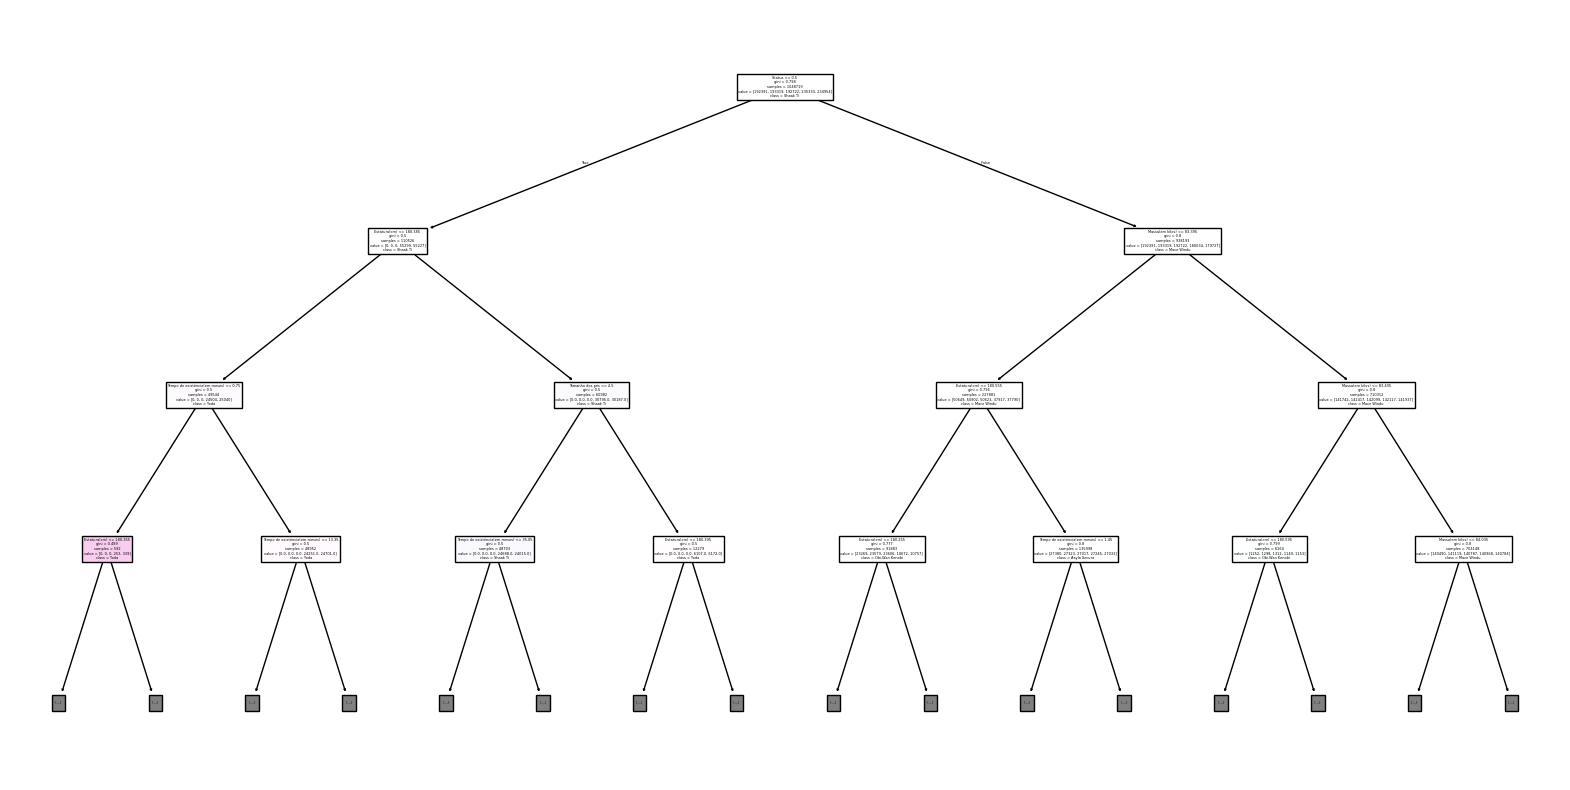

In [35]:
plt.figure(figsize=(20, 10))  # <-- Use isso em vez de plt.fig

tree.plot_tree(model_star, feature_names=star_caract, class_names=model_star.classes_ , filled=True, max_depth=3)
plt.show()
